<a href="https://colab.research.google.com/github/SantiagoMartinezHernandez/AR3D/blob/main/genga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting started with genga

Genga is our package for GWCNA + Co-expression networks analysis for gene expression analysis. This is a small example of the capabilities of the distribution and a little tutorial.

Please do not hesitate in contact us at as.martinez@uniandes.edu.co for any details.

## 1. Installation

You can simply use the PyPi package we've created

```
pip install genga
```

## 2. Example

Make sure to download the following subset of the paper data to use as an example. You can retrieve the [excel file from here](https://github.com/neurogen-uniandes/networks/blob/main/testgenga.xlsx) make sure to upload it.

The example presented is a subset of our data from *poecillia reticulata* (the guppy fish). It contains information of two female subjects that were exposed to a mating social context at 10 and 30 minutes.

![guppyfig1](https://raw.githubusercontent.com/neurogen-uniandes/networks/refs/heads/main/guppyfig1.png)


In [18]:
!pip install genga #we install the package from PyPi
from genga.functions import * #load every function from our package
df = load_df_from_xlsx("testgenga.xlsx") #load the example file, make sure to upload it first

# First step: structure

Since we want to build co-expression networks, we need to build the proper structure that describes our experimental complexity. We define said complexity by levels that can be seen as "layers".

In our example the order will be the following:

Treatment -> Time -> Nuclei

To provide that logical complexity we will create a dictionary: The keys on this dictionary are the columns from Excel file from which we will extract the data, the order in the dictionary will describe that logical order based on our experimentation.

In [21]:
structure = {"Time":{ #first layer of complexity: whether it is a 30 minute or 10 minute experiment
    10:{"Nuclei":["Dm","DI","Vs","Vd","Vv","POA","Hv","ATN","TPp"]}, #the seccond layer, that contains the nuclei of interest
    30:{"Nuclei":["Dm","DI","Vs","Vd","Vv","POA","Hv","ATN","TPp"]}
}}

#Based on the structure, we create a "genga structure" or a list of basal graphs
basal_graphs = generate_genga_structure(df,
                                    structure,
                                    nodes_info=["Female", "Gene", "IPI"],
                                    save_route="",
                                    corr_thr=0.3,
                                    corr_rule="standard")

Structure read
Time == 10 and Nuclei == "Dm" 
Time == 10 and Nuclei == "DI" 
Time == 10 and Nuclei == "Vs" 
Time == 10 and Nuclei == "Vd" 
Time == 10 and Nuclei == "Vv" 
Time == 10 and Nuclei == "POA" 
Time == 10 and Nuclei == "Hv" 
Time == 10 and Nuclei == "ATN" 
Time == 10 and Nuclei == "TPp" 
Time == 30 and Nuclei == "Dm" 
Time == 30 and Nuclei == "DI" 
Time == 30 and Nuclei == "Vs" 
Time == 30 and Nuclei == "Vd" 
Time == 30 and Nuclei == "Vv" 
Time == 30 and Nuclei == "POA" 
Time == 30 and Nuclei == "Hv" 
Time == 30 and Nuclei == "ATN" 
Time == 30 and Nuclei == "TPp" 
Dataframes created


18it [00:00, 315.43it/s]


The basal graphs we created on the step above are created using a Pearson correlation between the subjects that share the same information we stablished over the structure dictionary, we can print these basal graphs to further understand how they work.

adjacency matrix 
             agap3     gria2   plekhf2     grin1     gria3     thap6    gria1a  \
agap3    1.000000  0.749264  0.527685 -0.000000 -0.000000 -0.000000 -0.000000   
gria2    0.749264  1.000000  0.000000 -0.000000 -0.000000 -0.000000 -0.000000   
plekhf2  0.527685  0.000000  1.000000 -0.000000 -0.000000 -0.000000  0.000000   
grin1   -0.000000 -0.000000 -0.000000  1.000000  0.842271 -0.000000 -0.000000   
gria3   -0.000000 -0.000000 -0.000000  0.842271  1.000000 -0.000000 -0.000000   
thap6   -0.000000 -0.000000 -0.000000 -0.000000 -0.000000  1.000000  0.468765   
gria1a  -0.000000 -0.000000  0.000000 -0.000000 -0.000000  0.468765  1.000000   
nlgn3   -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000   

         nlgn3  
agap3     -0.0  
gria2     -0.0  
plekhf2   -0.0  
grin1     -0.0  
gria3     -0.0  
thap6     -0.0  
gria1a    -0.0  
nlgn3      1.0  
centrality 
  {'agap3': 0.2857142857142857, 'gria2': 0.14285714285714285, 'plekhf2': 0.14285714285

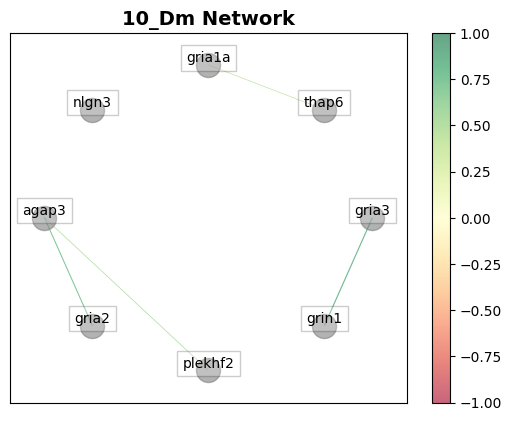

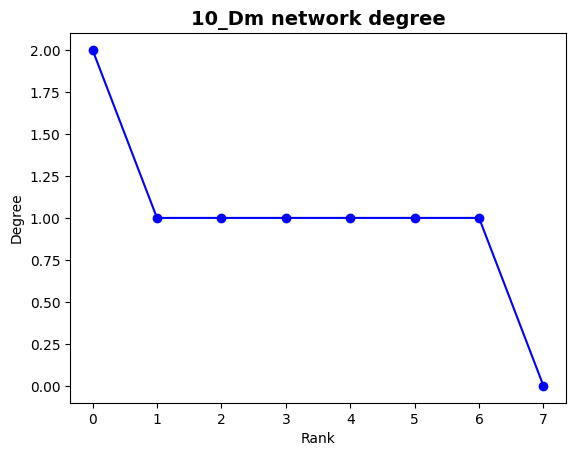

In [57]:
#print(basal_graphs) #as you can see a list of graphs is created for each nuclei

dm_nuclei_10_minutes = basal_graphs[0] # we take the first graph to use as an example
# in the same way, we can get relevant values such as:
print("adjacency matrix \n",dm_nuclei_10_minutes.get_adjacency_matrix()) #and the adjacency matrix
print("centrality \n ",dm_nuclei_10_minutes.get_centrality()) #the centrality
hfig, _ = dm_nuclei_10_minutes.get_degree(graphic=1) #the degree
dm_nuclei_10_minutes.get_graphic() #we can easily view the new graph containing the nuclei

Great! now we know how to work with basal networks. Now we will build co-expression networks by joining basal networks that share a characteristic, in this example the time (either 10 minutes or 30 minutes)

In [67]:
mating_10 , mating_30 = [], [] #We create empty lists to later append the basal graphs
for g in basal_graphs:
  graph_name = g.name.split("_") # we extract the name of the graph, it is formed by the complexity type
  if "10" in graph_name[0]:
    graph_name = g.name.split("_")[0] #we keep the name without the 10 separator
    mating_10.append(g)
  elif "30" in graph_name[0]:
    graph_name = g.name.split("_")[0]
    mating_30.append(g)


Then we will create the co-expression graph (named super graph within the documentation).

Co-expression graphs are build by comparing graphs with the same nodes, the edges between them would be a distance that can be euclidean, manhatan, canberra, Jaccard and DeltaCon.

[['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3'], ['agap3', 'gria2', 'plekhf2', 'grin1', 'gria3', 'thap6', 'gria1a', 'nlgn3']]
merging 10_Dm and 10_DI
merging 10_Dm and 10_Vs
merging 10_Dm and 10_Vd
merging 10_Dm and 10_Vv
merging 10_Dm and 10_POA
merging 10_Dm and 10_Hv
merging 10_Dm and 10_ATN
merging 10_Dm and 10_TPp
merging 10_DI and 10_Dm
merging 10_DI and 10_Vs
merging 10_DI and 10_Vd
merging 10_DI and 10_Vv
merging 10_DI a

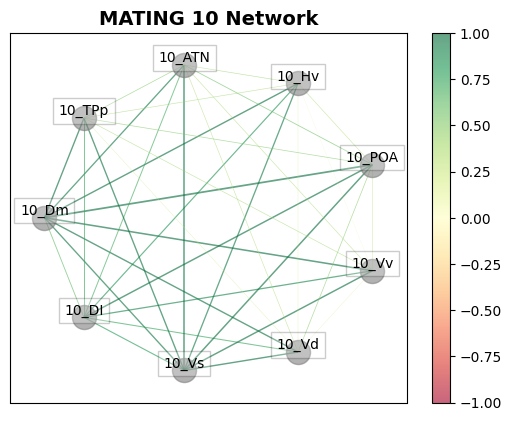

In [70]:

M10 = SuperGraph(name="MATING 10", #Name of the co-expression graph
                 graph_collection=mating_10, #List of the desired basal_graphs
                 method="euclidean", # The distance used to create the graphs
                 e_val=0) #parameter for the DeltaCon distance

M30 = SuperGraph(name="MATING 30", #Name of the co-expression graph
                 graph_collection=mating_30, #List of the desired basal_graphs
                 method="euclidean", # The distance used to create the graphs
                 e_val=0) #parameter for the DeltaCon distance
M10.get_graphic() # we plot the co-expression network
plt.show()

Now we have two co-expression graphs, one for Mating 10 minutes and one for Mating 30 minutes. We can extract relevant information from it such as the histogram, the modularity, a distance graph, among others.

           10_Dm     10_DI     10_Vs     10_Vd     10_Vv    10_POA     10_Hv  \
10_Dm   1.000000  0.663650  0.386741  0.360595  0.280832  0.201897  0.353455   
10_DI   0.663650  1.000000  0.522046  0.565525  0.440432  0.326280  0.486752   
10_Vs   0.386741  0.522046  1.000000  0.353455  0.329559  0.310367  0.406570   
10_Vd   0.360595  0.565525  0.353455  1.000000  0.951229  0.771052  0.932394   
10_Vv   0.280832  0.440432  0.329559  0.951229  1.000000  0.878095  0.980199   
10_POA  0.201897  0.326280  0.310367  0.771052  0.878095  1.000000  0.852144   
10_Hv   0.353455  0.486752  0.406570  0.932394  0.980199  0.852144  1.000000   
10_ATN  0.402524  0.600496  0.280832  0.852144  0.843665  0.704688  0.818731   
10_TPp  0.371577  0.588605  0.379083  0.932394  0.835270  0.771052  0.835270   

          10_ATN    10_TPp  
10_Dm   0.402524  0.371577  
10_DI   0.600496  0.588605  
10_Vs   0.280832  0.379083  
10_Vd   0.852144  0.932394  
10_Vv   0.843665  0.835270  
10_POA  0.704688  0.77105

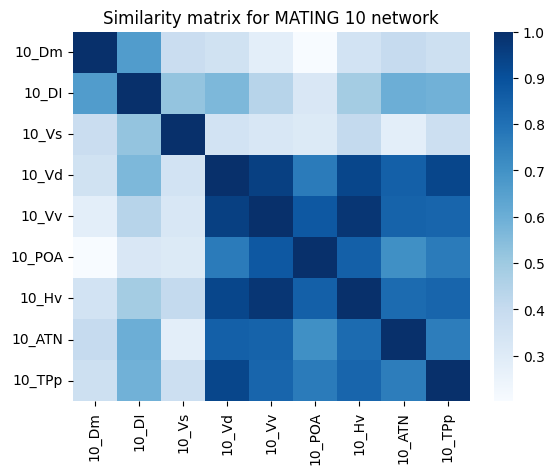

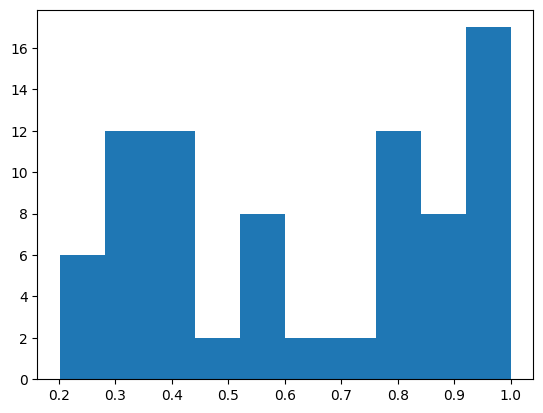

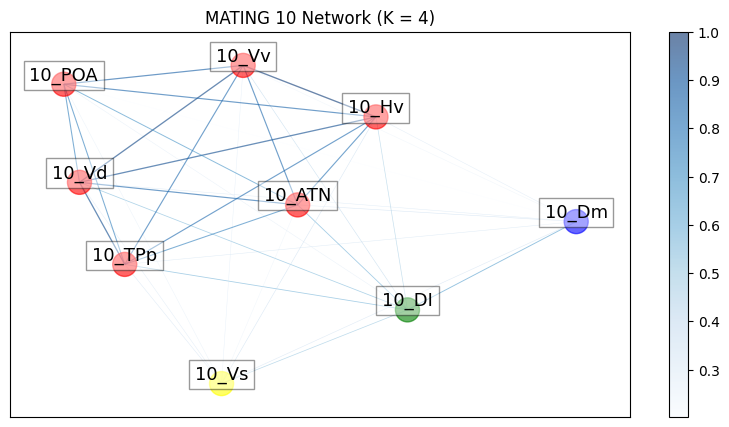

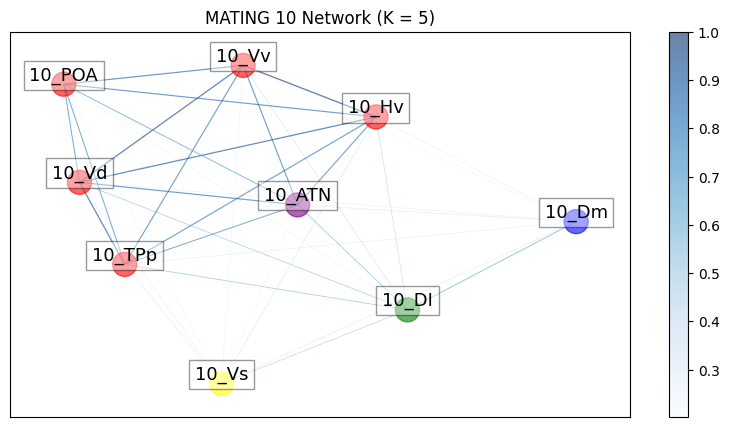

In [73]:
adj = M10.modify_adyancency(transform=True,alpha=1) # we normalize the adj matrix
M10.edge_histogram(adj,annot=False) # we plot the simmilarity matrix
fig, ax = plt.subplots()
fig = plt.hist(adj.flatten()) # we plot the edge histogram
for k in range (4,6):
    coms = M10.community_methods(adj,method="modularity",k=k)
    M10.get_distance_graph(adj,comms=coms) #we plot the organic communities formed given a number of partitions
plt.show()


Now you're ready to do your own research! if you have any doubts into how to use our library please write to

as.martinez@uniandes.edu.co